In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from owlready2 import *

onto = get_ontology("../ontologies/OntoHESS.owl").load()
load1 = onto.load1

In [10]:
df = pd.read_excel("../data/Artemis.xlsx")

v  = df['speed'].to_numpy(dtype=float)
t  = df['time'].to_numpy(dtype=float)
n  = len(df)
dt = np.concatenate(([1.0], np.diff(t)))

print(f"Cycle : {n} pas  |  duree {t[-1]/3600:.2f} h")
print(f"Vitesse max : {v.max()*3.6:.1f} km/h")
print(f"Distance    : {np.sum(v*dt)/1000:.2f} km")

Cycle : 14530 pas  |  duree 4.04 h
Vitesse max : 111.5 km/h
Distance    : 154.90 km


In [11]:
rho = load1.hasAirDensity[0]
S   = load1.hasFrontalArea[0]
Cx  = load1.hasCoeCx[0]

F_aero = 0.5 * rho * S * Cx * v**2
df['hasAeroForce'] = F_aero.round(2)

print(f"rho={rho}  S={S}  Cx={Cx}")
print(f"F_aero max : {F_aero.max():.2f} N")

rho=1.225  S=2.75  Cx=0.3
F_aero max : 484.74 N


In [12]:
m  = load1.hasTotalMass[0]
g  = load1.hasGravity[0]
c0 = load1.hasCoeC0[0]
c1 = load1.hasCoeC1[0]

F_roul = m * g * (c0 + c1 * v**2)
df['hasRollingForce'] = F_roul.round(2)

print(f"m={m} kg  g={g}  c0={c0}  c1={c1}")
print(f"F_roul max : {F_roul.max():.2f} N")

m=1400.0 kg  g=9.81  c0=0.008  c1=1.6e-06
F_roul max : 130.95 N


In [13]:
import math
alpha = load1.hasAlpha[0]

F_grav = m * g * math.sin(alpha)
df['hasGravityForce'] = round(F_grav, 2)

print(f"alpha={alpha} rad  F_grav={F_grav:.2f} N")

alpha=0.0 rad  F_grav=0.00 N


In [14]:
# ============================================================
# CELLULE : Nettoyage CSV + recalcul complet propre
# ============================================================
import pandas as pd
import numpy as np

# --- Chargement ---
df = pd.read_excel('../data/Artemis.xlsx')

# Supprimer les colonnes en doublon et garder uniquement time + speed
df = df[['time', 'speed']].copy()

N  = len(df)
dt = 1.0
speed = df['speed'].values  # m/s

# --- Parametres vehicule (notebook) ---
rho   = 1.225
S     = 2.75
Cx    = 0.3
m     = 1400.0
g     = 9.81
c0    = 0.008
c1    = 1.6e-6
alpha = 0.0
eta   = 0.92

# --- Forces ---
F_aero  = np.round(0.5 * rho * S * Cx * speed**2, 2)
F_roll  = np.round(m * g * (c0 + c1 * speed**2), 2)
F_grav  = np.full(N, round(m * g * np.sin(alpha), 2))

accel = np.zeros(N)
for i in range(N - 1):
    dv = speed[i+1] - speed[i]
    dt_i = df['time'].iloc[i+1] - df['time'].iloc[i]
    accel[i] = round(dv / dt_i, 2) if dt_i != 0 else 0.0
accel[N-1] = accel[N-2]

F_accel  = np.round(accel * m, 2)
F_total  = np.round(F_aero + F_roll + F_grav + F_accel, 2)
P_meca   = np.clip(np.round(F_total * speed, 2), -50000, None)
P_load   = np.where(P_meca >= 0, P_meca / eta, P_meca * eta)
P_load   = np.round(P_load, 2)

# --- Parametres batteries ---
V_EB      = 450.0
V_PB      = 400.0
E_EB_J    = 13709.89 * 3600.0
E_PB_J    = 2987.12  * 3600.0
E_EB_Wh   = 13709.89
E_PB_Wh   = 2987.12
P_EB_max  =  12600.0
P_EB_min  = -6300.0
P_PB_max  =  161040.0
P_PB_min  = -52338.0
SOC_EB_min = 0.20
SOC_PB_min = 0.20

# --- EMS Fig.10 ---
SOC_EB  = np.zeros(N)
SOC_PB  = np.zeros(N)
P_EB    = np.zeros(N)
P_PB    = np.zeros(N)
P_conv  = np.zeros(N)
I_EB    = np.zeros(N)
I_PB    = np.zeros(N)
I_load  = np.zeros(N)
I_prime = np.zeros(N)

SOC_EB[0] = 1.0
SOC_PB[0] = 1.0

for i in range(N):
    Pload_i   = P_load[i]
    I_load[i] = Pload_i / V_PB

    if (P_EB_min <= Pload_i <= P_EB_max) and (SOC_EB[i] > SOC_EB_min):
        P_EB[i] = Pload_i
        P_PB[i] = 0.0
    else:
        if SOC_EB[i] > SOC_EB_min:
            P_EB[i] = np.clip(Pload_i, P_EB_min, P_EB_max)
            P_PB[i] = Pload_i - P_EB[i]
        else:
            P_EB[i] = 0.0
            P_PB[i] = Pload_i

    P_PB[i]    = np.clip(P_PB[i], P_PB_min, P_PB_max)
    I_EB[i]    = P_EB[i] / V_EB
    I_PB[i]    = P_PB[i] / V_PB
    P_conv[i]  = P_EB[i] * (V_EB - V_PB) / V_EB
    I_prime[i] = P_conv[i] / (V_EB - V_PB) if (V_EB - V_PB) != 0 else 0.0

    if i < N - 1:
        SOC_EB[i+1] = np.clip(SOC_EB[i] - (P_EB[i] * dt) / E_EB_J, 0.0, 1.0)
        SOC_PB[i+1] = np.clip(SOC_PB[i] - (P_PB[i] * dt) / E_PB_J, 0.0, 1.0)

SOC_HESS = (SOC_EB * E_EB_Wh + SOC_PB * E_PB_Wh) / (E_EB_Wh + E_PB_Wh)

# --- Reconstruction CSV propre (colonnes uniques) ---
df['hasAeroForce']         = F_aero
df['hasRollingForce']      = F_roll
df['hasGravityForce']      = F_grav
df['hasAcceleration']      = accel
df['hasAccelerationForce'] = F_accel
df['hasTotalForce']        = F_total
df['hasPower']             = P_load
df['P_EB']                 = np.round(P_EB, 2)
df['P_PB']                 = np.round(P_PB, 2)
df['P_conv']               = np.round(P_conv, 4)
df['I_EB']                 = np.round(I_EB, 4)
df['I_PB']                 = np.round(I_PB, 4)
df['I_load']               = np.round(I_load, 4)
df['I_prime']              = np.round(I_prime, 4)
df['SOC_EB']               = np.round(SOC_EB, 6)
df['SOC_PB']               = np.round(SOC_PB, 6)
df['SOC_HESS']             = np.round(SOC_HESS, 6)

df.to_csv('../data/Artemis.csv', index=False)

print("CSV nettoye et recalcule.")
print(f"Colonnes finales ({len(df.columns)}) :", df.columns.tolist())
print(f"\nSOC_EB final  : {SOC_EB[-1]*100:.1f}%")
print(f"SOC_PB final  : {SOC_PB[-1]*100:.1f}%")
print(f"SOC_HESS final: {SOC_HESS[-1]*100:.1f}%")
print(f"P_load max    : {P_load.max()/1000:.2f} kW")
print(f"P_conv max    : {P_conv.max()/1000:.3f} kW")

CSV nettoye et recalcule.
Colonnes finales (19) : ['time', 'speed', 'hasAeroForce', 'hasRollingForce', 'hasGravityForce', 'hasAcceleration', 'hasAccelerationForce', 'hasTotalForce', 'hasPower', 'P_EB', 'P_PB', 'P_conv', 'I_EB', 'I_PB', 'I_load', 'I_prime', 'SOC_EB', 'SOC_PB', 'SOC_HESS']

SOC_EB final  : 20.0%
SOC_PB final  : 21.5%
SOC_HESS final: 20.2%
P_load max    : 44.23 kW
P_conv max    : 1.400 kW


In [15]:
df['hasTotalForce'] = (
    df['hasAeroForce'] +
    df['hasRollingForce'] +
    df['hasGravityForce'] +
    df['hasAccelerationForce']
).round(2)

print(f"F_tot max : {df['hasTotalForce'].max():.2f} N  |  min : {df['hasTotalForce'].min():.2f} N")

F_tot max : 4113.89 N  |  min : -5568.85 N


In [16]:
df['hasPower'] = (df['hasTotalForce'] * df['speed']).round(2)
df['hasPower'] = df['hasPower'].clip(lower=-50000)

E_traction = np.sum(np.maximum(df['hasPower'].values, 0) * dt) / 3600.0
E_freinage = np.sum(np.abs(np.minimum(df['hasPower'].values, 0)) * dt) / 3600.0
E_nette    = E_traction - E_freinage

print(f"P max : {df['hasPower'].max()/1000:.3f} kW  (article : 44.3 kW)")
print(f"P min : {df['hasPower'].min()/1000:.3f} kW  (article : -50.0 kW)")
print(f"E traction : {E_traction/1000:.3f} kWh")
print(f"E freinage : {E_freinage/1000:.3f} kWh")
print(f"E nette    : {E_nette/1000:.3f} kWh")

P max : 40.692 kW  (article : 44.3 kW)
P min : -50.000 kW  (article : -50.0 kW)
E traction : 19.576 kWh
E freinage : 8.809 kWh
E nette    : 10.767 kWh


In [17]:
# ============================================================
# CELLULE 1 : Chargement et exploration du fichier Artemis.csv
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement
df = pd.read_csv('../data/Artemis.csv')

print("Colonnes :", df.columns.tolist())
print("Shape :", df.shape)
print(df.head(10))
print("\nTypes :", df.dtypes)
print("\nStats :", df.describe())

Colonnes : ['time', 'speed', 'hasAeroForce', 'hasRollingForce', 'hasGravityForce', 'hasAcceleration', 'hasAccelerationForce', 'hasTotalForce', 'hasPower', 'P_EB', 'P_PB', 'P_conv', 'I_EB', 'I_PB', 'I_load', 'I_prime', 'SOC_EB', 'SOC_PB', 'SOC_HESS']
Shape : (14530, 19)
   time  speed  hasAeroForce  hasRollingForce  hasGravityForce  \
0     1    0.0           0.0           109.87              0.0   
1     2    0.0           0.0           109.87              0.0   
2     3    0.0           0.0           109.87              0.0   
3     4    0.0           0.0           109.87              0.0   
4     5    0.0           0.0           109.87              0.0   
5     6    0.0           0.0           109.87              0.0   
6     7    0.0           0.0           109.87              0.0   
7     8    0.0           0.0           109.87              0.0   
8     9    0.0           0.0           109.87              0.0   
9    10    0.0           0.0           109.87              0.0   

   

CSV mis a jour avec EMS courant corrige.

SOC_EB final  : 20.1%
SOC_PB final  : 21.1%
SOC_HESS final: 20.2%
I_EB max      : 28.00 A  (limite : 28.00 A)
I_EB min      : -14.00 A  (limite : -14.00 A)
P_conv max    : 1.327 kW
P_conv min    : -0.664 kW


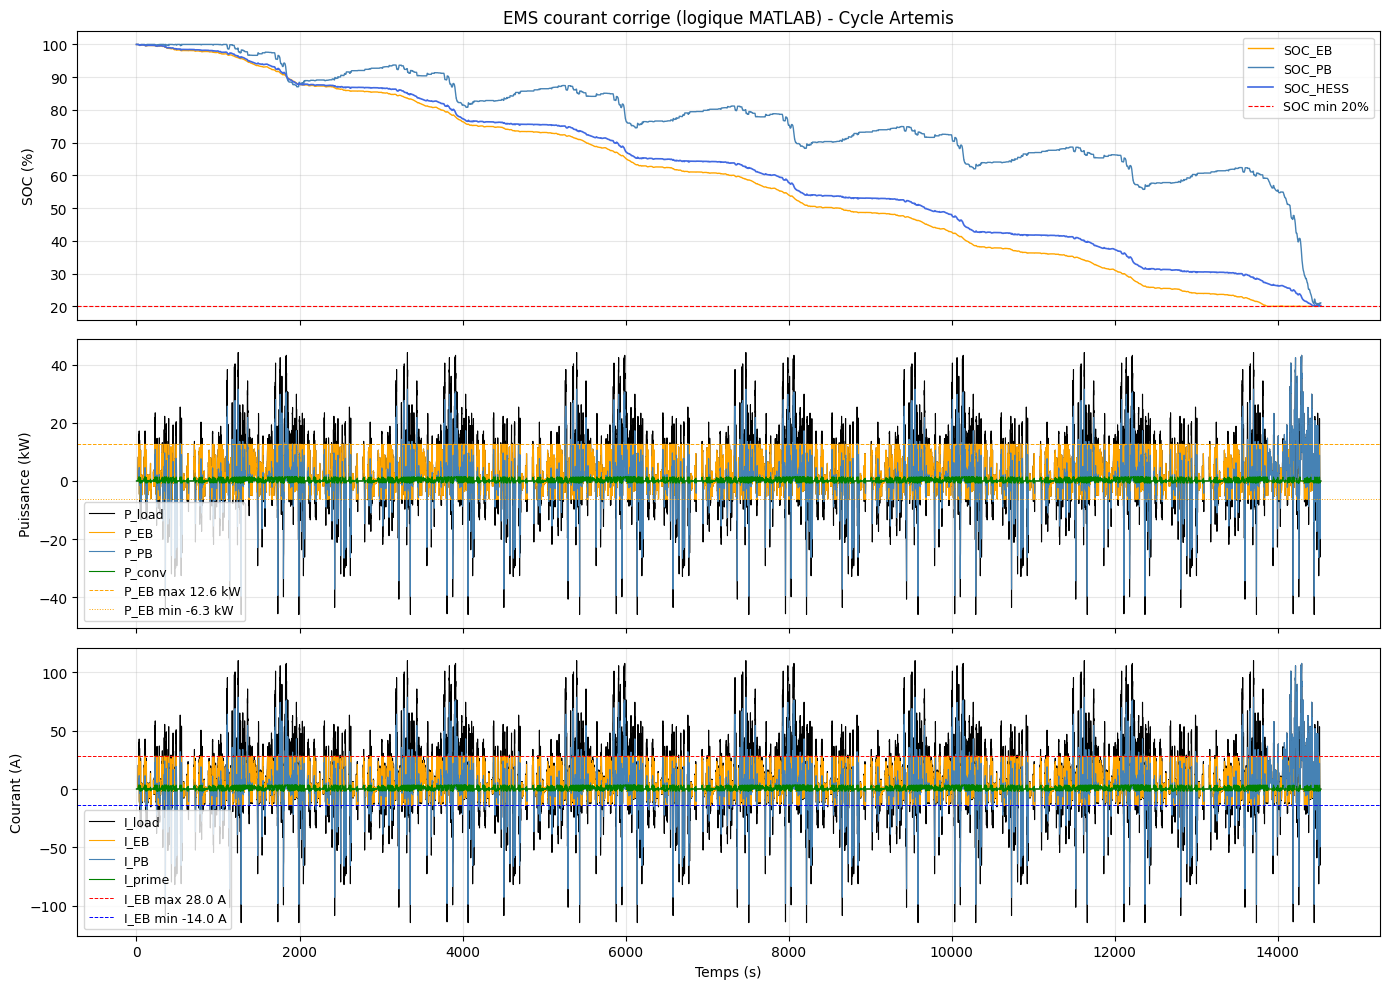

In [18]:
# ============================================================
# CELLULE : EMS courant (logique MATLAB du papier) - corrige
# Ibe = I_charge * Vbp / Vbe
# I_prime = Ibe * (Vbe - Vbp) / Vbp
# Ibp = I_charge - Ibe - I_prime
# P_conv = Ibe * (Vbe - Vbp)  (Eq.8 papier)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Artemis.csv')
N  = len(df)
dt = 1.0

# --- Parametres ---
V_EB     = 450.0
V_PB     = 402.60
E_EB_J   = 13709.89 * 3600.0
E_PB_J   = 2987.12  * 3600.0
E_EB_Wh  = 13709.89
E_PB_Wh  = 2987.12

# Limites courant EB
Ibe_decharge =  12600.0 / V_EB   # +28.00 A
Ibe_recharge = -6300.0  / V_EB   # -14.00 A

# Limites courant PB
Ibp_decharge =  161040.0 / V_PB  # +402.6 A
Ibp_recharge = -52338.0  / V_PB  # -130.8 A

# Courant de charge
P_load   = df['hasPower'].values
I_charge = P_load / V_PB

# --- Simulation ---
SOC_EB  = np.zeros(N)
SOC_PB  = np.zeros(N)
I_EB    = np.zeros(N)
I_PB    = np.zeros(N)
I_conv  = np.zeros(N)
I_arr   = np.zeros(N)

SOC_EB[0] = 1.0
SOC_PB[0] = 1.0

for i in range(N):
    # Ibe = I_charge * Vbp / Vbe
    Ibe = I_charge[i] * V_PB / V_EB

    # Saturation Ibe dans ses limites
    Ibe = np.clip(Ibe, Ibe_recharge, Ibe_decharge)

    # Si SOC_EB epuise et demande de decharge : Ibe = 0
    if SOC_EB[i] <= 0.2 and I_charge[i] > 0:
        Ibe = 0.0

    # Courant convertisseur (logique MATLAB)
    I_prime_i = Ibe * (V_EB - V_PB) / V_PB

    # Courant PB : complement
    Ibp = I_charge[i] - Ibe - I_prime_i
    Ibp = np.clip(Ibp, Ibp_recharge, Ibp_decharge)

    I_arr[i]  = Ibe
    I_EB[i]   = Ibe
    I_PB[i]   = Ibp
    I_conv[i] = I_prime_i

    # Puissances (Eq.8 du papier : P_conv = I_EB * (Vbe - Vbp))
    P_EB_i   = Ibe * V_EB
    P_PB_i   = Ibp * V_PB
    P_conv_i = Ibe * (V_EB - V_PB)

    # Mise a jour SOC
    if i < N - 1:
        SOC_EB[i+1] = np.clip(SOC_EB[i] - (P_EB_i * dt) / E_EB_J, 0.0, 1.0)
        SOC_PB[i+1] = np.clip(SOC_PB[i] - (P_PB_i * dt) / E_PB_J, 0.0, 1.0)

SOC_HESS = (SOC_EB * E_EB_Wh + SOC_PB * E_PB_Wh) / (E_EB_Wh + E_PB_Wh)

P_EB   = I_EB * V_EB
P_PB   = I_PB * V_PB
P_conv = I_EB * (V_EB - V_PB)

# --- Sauvegarde ---
df['SOC_EB']   = np.round(SOC_EB,  6)
df['SOC_PB']   = np.round(SOC_PB,  6)
df['SOC_HESS'] = np.round(SOC_HESS,6)
df['I_EB']     = np.round(I_EB,    4)
df['I_PB']     = np.round(I_PB,    4)
df['I_prime']  = np.round(I_conv,  4)
df['I_load']   = np.round(I_charge,4)
df['P_EB']     = np.round(P_EB,    2)
df['P_PB']     = np.round(P_PB,    2)
df['P_conv']   = np.round(P_conv,  4)
df.to_csv('../data/Artemis.csv', index=False)
print("CSV mis a jour avec EMS courant corrige.")

# --- Resume ---
print(f"\nSOC_EB final  : {SOC_EB[-1]*100:.1f}%")
print(f"SOC_PB final  : {SOC_PB[-1]*100:.1f}%")
print(f"SOC_HESS final: {SOC_HESS[-1]*100:.1f}%")
print(f"I_EB max      : {I_EB.max():.2f} A  (limite : {Ibe_decharge:.2f} A)")
print(f"I_EB min      : {I_EB.min():.2f} A  (limite : {Ibe_recharge:.2f} A)")
print(f"P_conv max    : {P_conv.max()/1000:.3f} kW")
print(f"P_conv min    : {P_conv.min()/1000:.3f} kW")

# --- Graphiques ---
time = df['time'].values - df['time'].values[0]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(time, SOC_EB   * 100, label='SOC_EB',   color='orange',    linewidth=1.0)
axes[0].plot(time, SOC_PB   * 100, label='SOC_PB',   color='steelblue', linewidth=1.0)
axes[0].plot(time, SOC_HESS * 100, label='SOC_HESS', color='royalblue', linewidth=1.2)
axes[0].axhline(20, color='red', linestyle='--', linewidth=0.8, label='SOC min 20%')
axes[0].set_ylabel('SOC (%)')
axes[0].set_title('EMS courant corrige (logique MATLAB) - Cycle Artemis')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, P_load / 1000, label='P_load', color='black',     linewidth=0.8)
axes[1].plot(time, P_EB   / 1000, label='P_EB',   color='orange',    linewidth=0.8)
axes[1].plot(time, P_PB   / 1000, label='P_PB',   color='steelblue', linewidth=0.8)
axes[1].plot(time, P_conv / 1000, label='P_conv', color='green',     linewidth=0.8)
axes[1].axhline( 12600 / 1000, color='orange', linestyle='--', linewidth=0.7, label='P_EB max 12.6 kW')
axes[1].axhline(-6300  / 1000, color='orange', linestyle=':',  linewidth=0.7, label='P_EB min -6.3 kW')
axes[1].set_ylabel('Puissance (kW)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].plot(time, I_charge, label='I_load',  color='black',     linewidth=0.8)
axes[2].plot(time, I_EB,     label='I_EB',    color='orange',    linewidth=0.8)
axes[2].plot(time, I_PB,     label='I_PB',    color='steelblue', linewidth=0.8)
axes[2].plot(time, I_conv,   label='I_prime', color='green',     linewidth=0.8)
axes[2].axhline(Ibe_decharge, color='red',  linestyle='--', linewidth=0.7, label=f'I_EB max {Ibe_decharge:.1f} A')
axes[2].axhline(Ibe_recharge, color='blue', linestyle='--', linewidth=0.7, label=f'I_EB min {Ibe_recharge:.1f} A')
axes[2].set_ylabel('Courant (A)')
axes[2].set_xlabel('Temps (s)')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../resultats/EMS_courant_MATLAB_corrige.png', dpi=150, bbox_inches='tight')
plt.show()